In [55]:
import pandas as pd

In [56]:
# 1. Load the pristine training data
df = pd.read_csv("../data/final_training_data.csv")
# Ensure it is sorted chronologically
df = df.sort_values('HOME_GAME_DATE').reset_index(drop=True)
df

,HOME_TEAM_ABBREVIATION,GAME_ID,HOME_GAME_DATE,HOME_MATCHUP,HOME_WL,AWAY_TEAM_ABBREVIATION,AWAY_GAME_DATE,AWAY_MATCHUP,AWAY_WL,HOME_PTS_EMA_10,...,AWAY_AST_EMA_10,AWAY_TOV_EMA_10,AWAY_PF_EMA_10,AWAY_FG_PCT_EMA_15,AWAY_FG3_PCT_EMA_15,AWAY_FT_PCT_EMA_15,AWAY_OREB_EMA_15,AWAY_DREB_EMA_15,AWAY_STL_EMA_15,AWAY_BLK_EMA_15
0,PHI,22100021,2021-10-22,PHI vs. BKN,0,BKN,2021-10-22,BKN @ PHI,1,117.000000,...,19.000000,13.000000,17.000000,0.440000,0.531000,0.565000,5.000000,39.000000,3.000000,9.000000
1,WAS,22100019,2021-10-22,WAS vs. IND,1,IND,2021-10-22,IND @ WAS,0,98.000000,...,29.000000,17.000000,24.000000,0.467000,0.362000,0.875000,8.000000,43.000000,2.000000,10.000000
2,SAC,22100026,2021-10-22,SAC vs. UTA,0,UTA,2021-10-22,UTA @ SAC,1,124.000000,...,18.000000,10.000000,19.000000,0.440000,0.298000,0.867000,12.000000,41.000000,6.000000,5.000000
3,ORL,22100018,2021-10-22,ORL vs. NYK,0,NYK,2021-10-22,NYK @ ORL,1,97.000000,...,27.000000,19.000000,22.000000,0.486000,0.378000,0.704000,7.000000,48.000000,9.000000,10.000000
4,LAL,22100025,2021-10-22,LAL vs. PHX,0,PHX,2021-10-22,PHX @ LAL,1,114.000000,...,23.000000,18.000000,18.000000,0.414000,0.378000,0.706000,11.000000,34.000000,9.000000,3.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6119,SAS,22501197,2026-04-12,SAS vs. DEN,0,DEN,2026-04-12,DEN @ SAS,1,125.083040,...,32.013539,12.613445,19.129038,0.511688,0.412707,0.831212,10.062508,36.639838,7.084003,4.307993
6120,POR,22501200,2026-04-12,POR vs. SAC,1,SAC,2026-04-12,SAC @ POR,0,115.796499,...,25.509157,15.242238,19.763033,0.478895,0.349105,0.734687,13.137284,30.829206,7.548378,4.798228
6121,MIN,22501195,2026-04-12,MIN vs. NOP,1,NOP,2026-04-12,NOP @ MIN,0,117.481208,...,24.514560,14.293467,19.733100,0.472253,0.353084,0.781191,11.097437,32.103362,8.958111,5.671702
6122,OKC,22501196,2026-04-12,OKC vs. PHX,0,PHX,2026-04-12,PHX @ OKC,1,122.290740,...,21.890146,15.351804,19.776964,0.442970,0.335692,0.746897,13.077608,29.204414,8.261815,4.867081


In [57]:
# 2. Define our Features (X) and our Target (y)
# We exclude the identifiers from the feature set so the model doesn't learn names/dates
features = [col for col in df.columns if 'EMA' in col]
target = 'HOME_WL'


In [58]:
# 3. Chronological Split (Train on the first 80% of games, Test on the last 20%)
split_index = int(len(df) * 0.80)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]
# Extract X and y matrices
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]
print(f"Training on {len(X_train)} games (Past)")
print(f"Testing on {len(X_test)} games (Future)")
print(f"Number of Features: {len(features)}")

Training on 4899 games (Past)
Testing on 1225 games (Future)
Number of Features: 22


Scaling

In [59]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit and Transform the Training Data

X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the Testing Data
X_test_scaled = scaler.transform(X_test)

print("Data successfully scaled! ")


Data successfully scaled! 


### Logistic Regression

The Limitation (Why it fails in sports): Basketball is not a straight line. It is highly non-linear. Imagine a team that shoots horribly from 3-point range (which usually means a Loss). BUT, they grab 20 offensive rebounds a game, allowing them to overcome their bad shooting. Logistic Regression cannot comprehend that "If-This-Then-That" nuance. It just sees the bad 3-point shooting and drags the prediction toward a Loss. It cannot bend its decision boundary.


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# We will create a dictionary to store the accuracies of all our models as we build them
model_results = {}

# 1. Initialize the Statistical Model
log_reg = LogisticRegression(random_state=42)

# 2. Train the Model (using the SCALED training data)
log_reg.fit(X_train_scaled, y_train)

# 3. Predict the Future (2025-26 season)
y_pred_lr = log_reg.predict(X_test_scaled)

# 4. Evaluate
acc_lr = accuracy_score(y_test, y_pred_lr)
model_results['Logistic Regression'] = acc_lr

print(f"Logistic Regression Baseline Accuracy: {acc_lr * 100:.2f}%")


Logistic Regression Baseline Accuracy: 62.61%


### SVM

In [61]:
from sklearn.svm import SVC

print("Training SVM...")
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
acc_svm = accuracy_score(y_test, svm_model.predict(X_test_scaled))
model_results['SVM'] = acc_svm
print(f"SVM Accuracy: {acc_svm * 100:.2f}%")

Training SVM...
SVM Accuracy: 60.57%


### Random Forest

In [62]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
acc_rf = accuracy_score(y_test, rf_model.predict(X_test_scaled))
model_results['Random Forest'] = acc_rf
print(f"Random Forest Accuracy: {acc_rf * 100:.2f}%")

Training Random Forest...
Random Forest Accuracy: 60.49%


### XGBoost

In [63]:
import xgboost as xgb

print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
xgb_model.fit(X_train_scaled, y_train) 
acc_xgb = accuracy_score(y_test, xgb_model.predict(X_test_scaled))
model_results['XGBoost'] = acc_xgb
print(f"XGBoost Accuracy: {acc_xgb * 100:.2f}%")

Training XGBoost...
XGBoost Accuracy: 60.08%


### HYPER-PARAM TUNING

In [64]:
tscv = TimeSeriesSplit(n_splits=5) # Expanded to 5 splits

models = {
    'Logistic Regression': (LogisticRegression(max_iter=2000), {
        'C': [0.01, 0.1, 1, 10], 
        'penalty': ['l1', 'l2'], 
        'solver': ['liblinear', 'saga']
    }),
    'SVM': (SVC(probability=True), {
        'C': [0.1, 1, 10], 
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto']
    }),
    'Random Forest': (RandomForestClassifier(random_state=42), {
        'n_estimators': [100, 200, 300], 
        'max_depth': [3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'max_features': ['sqrt', 'log2']
    }),
    'XGBoost': (xgb.XGBClassifier(random_state=42, eval_metric='logloss'), {
        'learning_rate': [0.01, 0.05, 0.1], 
        'max_depth': [3, 5, 7],
        'n_estimators': [100, 200],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    })
}
print("Exhaustive grids initialized.")


Exhaustive grids initialized.


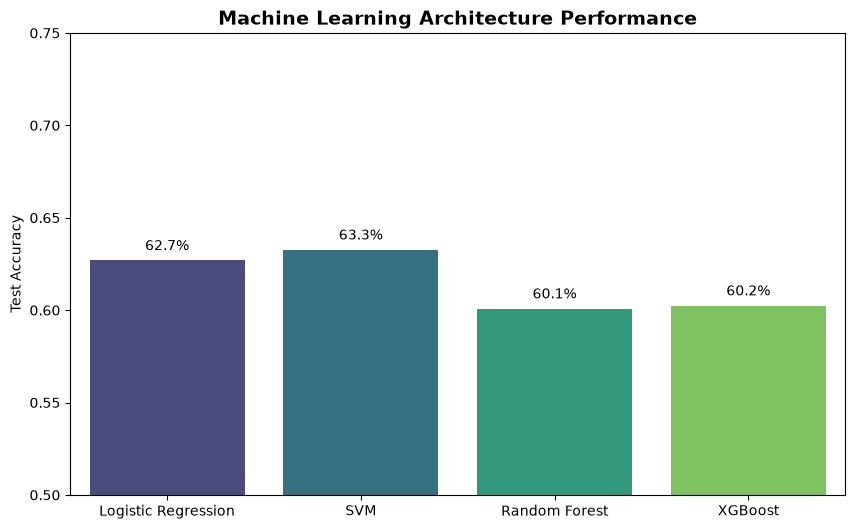

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Model Comparison Bar Chart ---
plt.figure(figsize=(10, 6))
model_names = list(tuned_results.keys())
accuracies = list(tuned_results.values())
# Create a beautiful barplot
ax = sns.barplot(x=model_names, y=accuracies, palette='viridis')
# Add the exact percentage on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()*100:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.ylim(0.5, 0.75) # Zoom in to see the differences clearly
plt.title('Machine Learning Architecture Performance', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy')
plt.show()


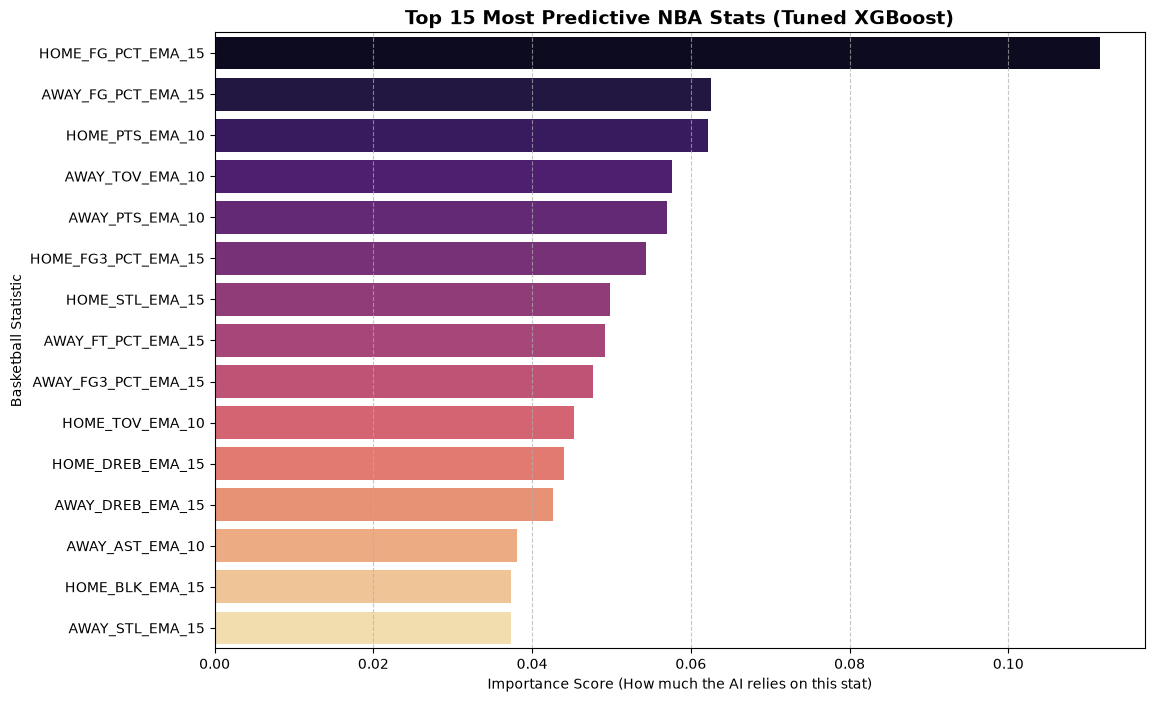

In [66]:
importances = best_models['XGBoost'].feature_importances_
# 2. Glue the math scores back to your original column names
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})
# 3. Sort them from highest to lowest and grab the Top 15
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)
# 4. Plot a beautiful custom bar chart
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')
plt.title("Top 15 Most Predictive NBA Stats (Tuned XGBoost)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score (How much the AI relies on this stat)")
plt.ylabel("Basketball Statistic")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## The Grand Tournament (GridSearchCV A/B Test)
Proving the ROI of the new features across all algorithms.

### 1. Data Loading & Strict Chronological Splitting
We load both pipelines simultaneously and split them so the models only ever test on the 2025 season.

In [67]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load Data
df_base = pd.read_csv("../data/final_training_data_baseline.csv")
df_eng = pd.read_csv("../data/final_training_data_engineered.csv")

def chronological_split(df):
    df = df.copy()
    df['Season_Start'] = pd.to_datetime(df['HOME_GAME_DATE']).dt.year
    df['Season_Month'] = pd.to_datetime(df['HOME_GAME_DATE']).dt.month
    df['Season'] = np.where(df['Season_Month'] > 7, df['Season_Start'], df['Season_Start'] - 1)
    train = df[df['Season'] < 2025]
    test = df[df['Season'] == 2025]
    return train, test

train_base, test_base = chronological_split(df_base)
train_eng, test_eng = chronological_split(df_eng)

drop_cols = ['HOME_TEAM_ABBREVIATION', 'AWAY_TEAM_ABBREVIATION', 'GAME_ID', 'HOME_GAME_DATE', 
             'AWAY_GAME_DATE', 'HOME_MATCHUP', 'AWAY_MATCHUP', 'HOME_WL', 'AWAY_WL', 
             'Season_Start', 'Season_Month', 'Season']

def get_X_y(train, test):
    actual_drop = [col for col in drop_cols if col in train.columns]
    X_train = train.drop(columns=actual_drop)
    y_train = train['HOME_WL']
    X_test = test.drop(columns=actual_drop)
    y_test = test['HOME_WL']
    return X_train, y_train, X_test, y_test

X_train_base, y_train_base, X_test_base, y_test_base = get_X_y(train_base, test_base)
X_train_eng, y_train_eng, X_test_eng, y_test_eng = get_X_y(train_eng, test_eng)

scaler_base = StandardScaler()
X_train_base_scaled = scaler_base.fit_transform(X_train_base)
X_test_base_scaled = scaler_base.transform(X_test_base)

scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)
print("Data loaded and scaled successfully.")

Data loaded and scaled successfully.


### 2. The Model Zoo & Grid Setup
We define the hyperparameter search spaces for Logistic Regression, SVM, Random Forest, and XGBoost. We use `TimeSeriesSplit` to prevent look-ahead bias during tuning.

In [68]:
tscv = TimeSeriesSplit(n_splits=3) # Use 3 splits to prevent overfitting

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), {'C': [0.1, 1], 'solver': ['liblinear']}),
    'SVM': (SVC(), {'C': [0.1, 1], 'kernel': ['linear', 'rbf']}),
    'Random Forest': (RandomForestClassifier(random_state=42), {'n_estimators': [50, 100], 'max_depth': [3, 5]}),
    'XGBoost': (xgb.XGBClassifier(random_state=42), {'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]})
}
print("Grids reverted to regularized constraints.")


Grids reverted to regularized constraints.


### 3. Execution (The Tournament)
> **WARNING:** This cell will take time to run (potentially 5-10 minutes). It executes GridSearchCV for every model on BOTH datasets, effectively training hundreds of models in the background.

In [69]:
tournament_results = []

for model_name, (model, param_grid) in models.items():
    print(f"Tuning {model_name}...")
    
    # Baseline
    grid_base = GridSearchCV(model, param_grid, cv=tscv, scoring='accuracy', n_jobs=-1)
    grid_base.fit(X_train_base_scaled, y_train_base)
    acc_base = accuracy_score(y_test_base, grid_base.best_estimator_.predict(X_test_base_scaled))
    tournament_results.append({'Model': model_name, 'Dataset': 'Baseline', 'Accuracy': acc_base * 100})
    
    # Engineered
    grid_eng = GridSearchCV(model, param_grid, cv=tscv, scoring='accuracy', n_jobs=-1)
    grid_eng.fit(X_train_eng_scaled, y_train_eng)
    acc_eng = accuracy_score(y_test_eng, grid_eng.best_estimator_.predict(X_test_eng_scaled))
    tournament_results.append({'Model': model_name, 'Dataset': 'Engineered', 'Accuracy': acc_eng * 100})

results_df = pd.DataFrame(tournament_results)
print("Tournament Complete!")

Tuning Logistic Regression...
Tuning SVM...
Tuning Random Forest...
Tuning XGBoost...
Tournament Complete!


### 4. ROI Visualization
We overlay the accuracy of the Baseline vs Engineered pipelines on a grouped bar chart to prove the value of our math.

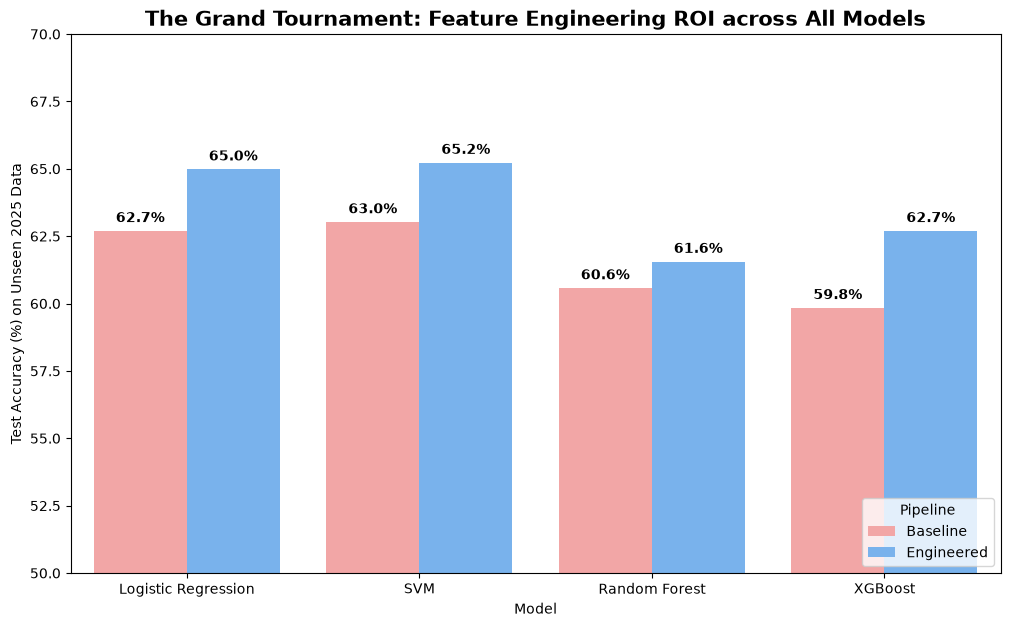

In [70]:
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Model', y='Accuracy', hue='Dataset', data=results_df, palette=['#FF9999', '#66B2FF'])

plt.ylim(50, 70)
plt.title("The Grand Tournament: Feature Engineering ROI across All Models", fontsize=15, fontweight='bold')
plt.ylabel("Test Accuracy (%) on Unseen 2025 Data")
plt.legend(title='Pipeline', loc='lower right')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

plt.show()

### 5. Feature Importances & Model Persistence
Now that we have proven the superiority of the engineered pipeline, we will extract the exact weights the best Logistic Regression model is using, plot them, and save the model to disk for our UI.

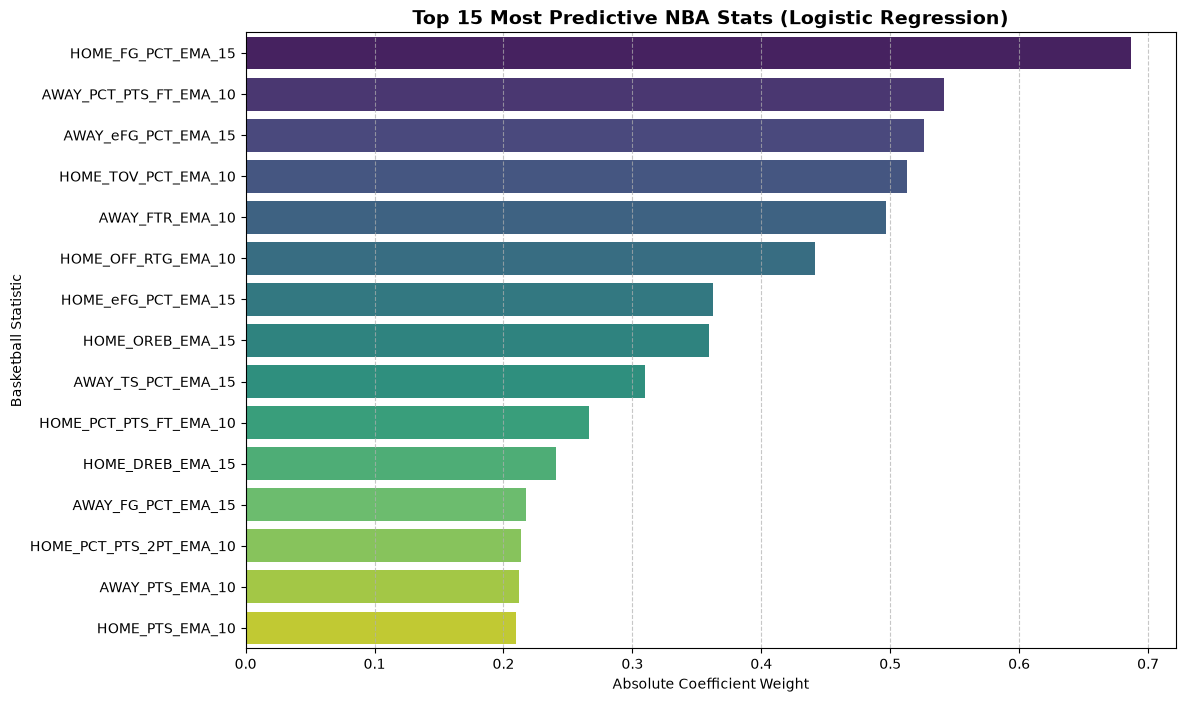

Model and Scaler successfully saved to the /models directory!


In [71]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Re-fit the best Logistic Regression on the full Engineered Dataset
# We use the tightly regularized grid to prevent overfitting
best_logreg = GridSearchCV(LogisticRegression(max_iter=1000), {'C': [0.1, 1], 'solver': ['liblinear']}, cv=tscv, scoring='accuracy', n_jobs=-1)
best_logreg.fit(X_train_eng_scaled, y_train_eng)

# 2. Extract Coefficients
coefs = best_logreg.best_estimator_.coef_[0]
features = X_train_eng.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': abs(coefs) # We take absolute value to see magnitude of impact
})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

# 3. Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Top 15 Most Predictive NBA Stats (Logistic Regression)", fontsize=14, fontweight='bold')
plt.xlabel("Absolute Coefficient Weight")
plt.ylabel("Basketball Statistic")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. Save the Model and Scaler
joblib.dump(best_logreg.best_estimator_, '../models/best_logreg_model.pkl')
joblib.dump(scaler_eng, '../models/scaler.pkl')
print("Model and Scaler successfully saved to the /models directory!")
